## EDA

In [8]:
from src.eda import *

In [9]:
df= pd.read_csv(r'D:\Vu Xuan Bach\NEU-HK7\Deep Learning\final_dl\data\ETTh1.csv')

In [10]:

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')


# Sắp xếp lại theo thời gian (nếu chưa được sắp xếp)
df = df.sort_values(by='date')
# Set index cho cột Time
df.set_index('date', inplace=True)
eda = WindPowerEDA(df)

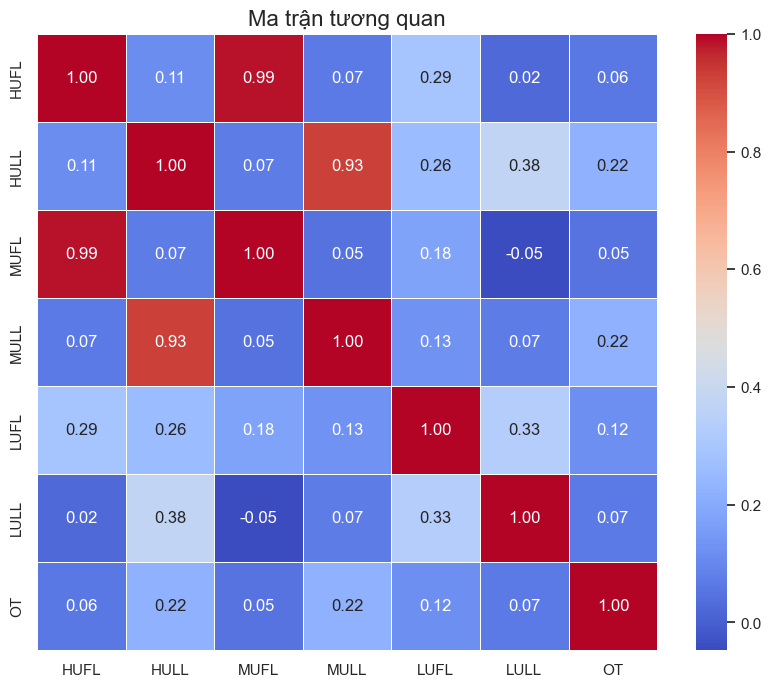

In [11]:
eda.plot_correlation_heatmap()

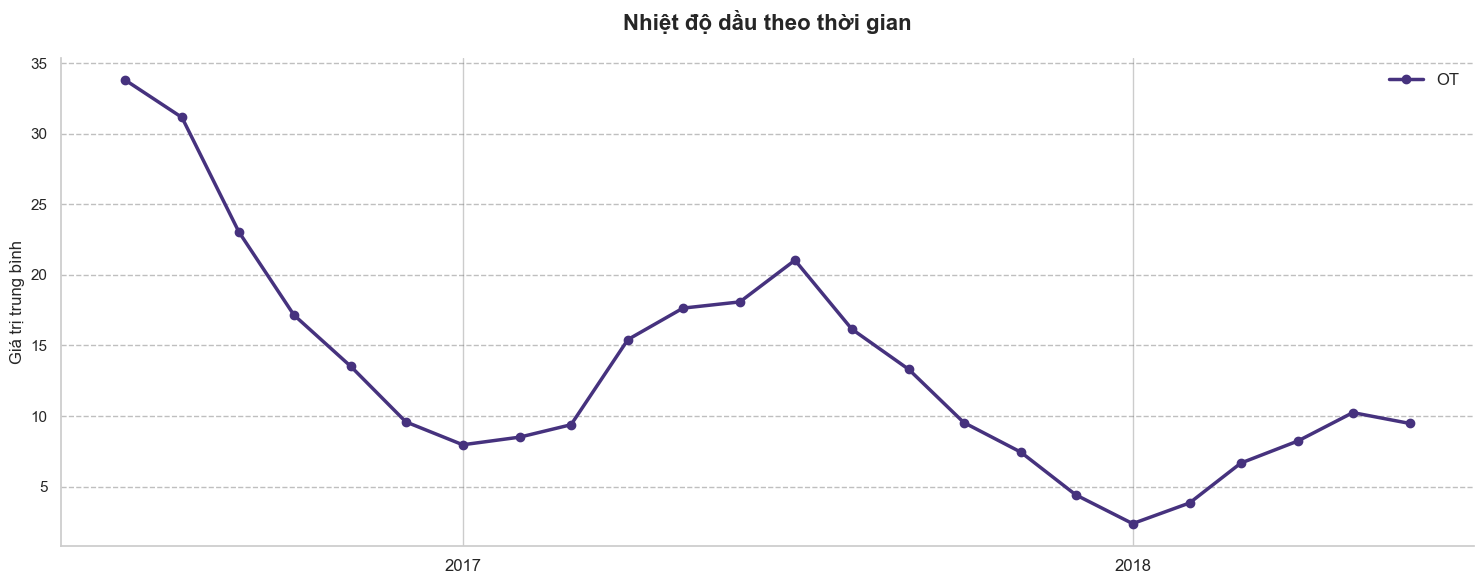

In [12]:
eda.plot_monthly(columns=['OT'], title="Nhiệt độ dầu theo thời gian")


d:\Vu Xuan Bach\NEU-HK7\Deep Learning\final_dl\src\eda.py:149: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  series = self.df[column].resample(resample_rule).mean().dropna()


Đang phân rã với period = 24...


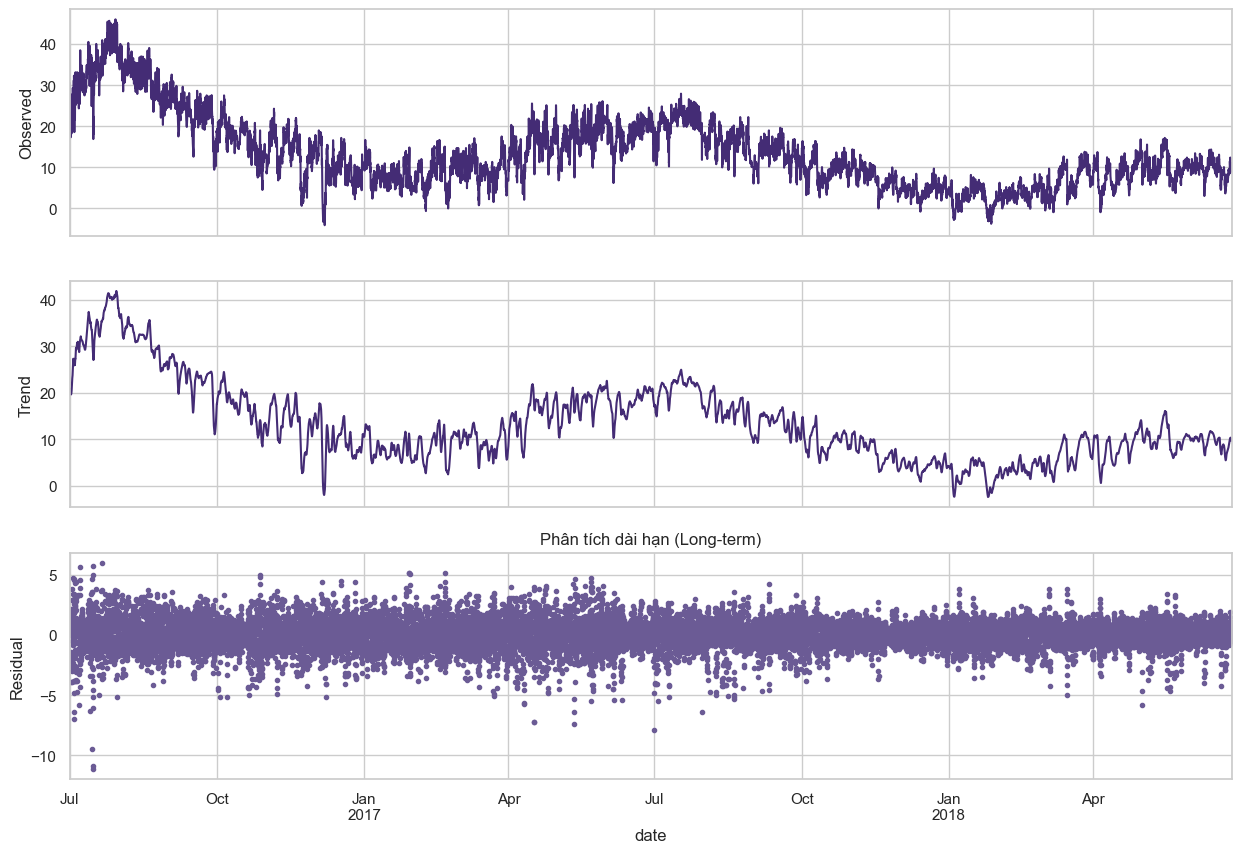

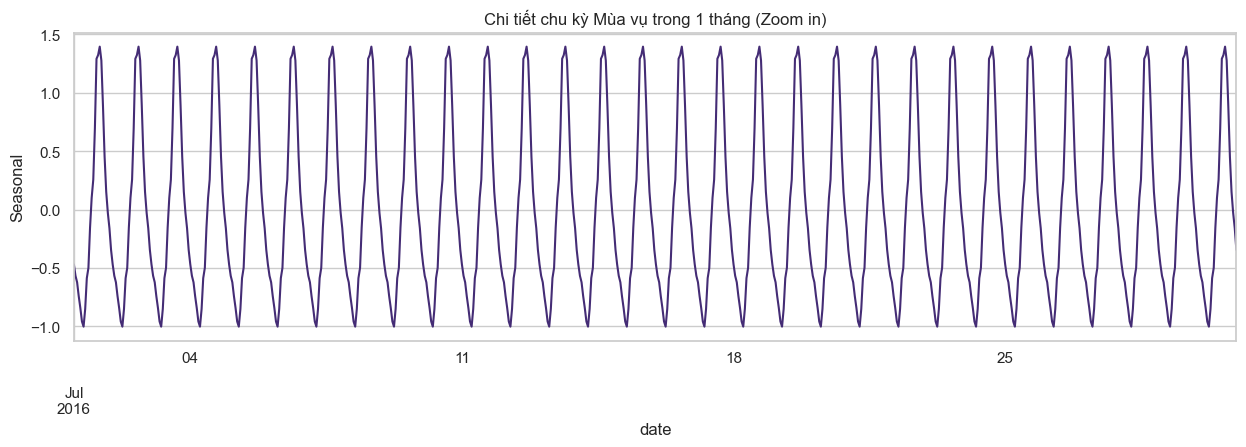

In [13]:
eda.plot_decomposition(column='OT', resample_rule='H')

### 1. Long-term Trend Analysis (Trend Component)
*Based on the Full Dataset chart*
- **Yearly Seasonality:**
    - The temperature trend follows a distinct climatic pattern: Peaking in summer (July-August) and bottoming out in winter (January-February).
- **Data Drift/Anomaly:**
    - There is a significant difference in amplitude between the years.
    - **2016:** Very high temperature peaks (**~40°C - 42°C**).
    - **2017:** Significantly lower temperature peaks (**~25°C - 28°C**).
    - **Insight:** This ~15°C difference suggests that oil temperature depends not only on time (season) but also heavily on **Power Load** or changes in equipment operation.

### 2. Short-term Cycle Analysis (Seasonal Component)
*Based on the 1-month Zoom-in chart (first 720 hours)*

- **Cycle:**
    - Observing a one-week period (e.g., from day 04 to 11), exactly 7 wave peaks appear.
    - **Conclusion:** The data exhibits **Daily Seasonality (24H)**. The rise and fall pattern repeats exactly every 24 hours.
- **Amplitude:**
    - Fluctuates between **-1.0 and +1.4**. The total amplitude is approximately **2.4°C**.
    - **Comparison:** The daily amplitude (2.4°C) is much smaller than the yearly amplitude (40°C). This implies: *Time of day determines minor fluctuations, while Season determines the baseline temperature.*
- **Wave Shape:** A sawtooth shape with steep slopes, reflecting the rapid heating/cooling rate of the transformer during day/night load changes.

### 3. Noise & Anomaly Analysis (Residual Component)
*Based on the full Residual chart*

- **Distribution:** Most noise is clustered around the 0 axis (within the ±2.5 range), indicating that the decomposition model performs well.
- **Outliers:**
    - Many **Deep Negative Residuals** appear (dropping to -5 to -10).
    - **Physical Meaning:** The actual temperature is much lower than predicted. This is highly likely due to **Power Outages/Load Shedding** or sudden heavy rain causing the transformer to cool down abnormally fast.

--- Kết quả kiểm định ADF cho cột: OT ---
ADF Statistic: -3.4880
p-value: 0.0083
Critical Values:
	1%: -3.4307
	5%: -2.8617
	10%: -2.5669
=> Kết luận: Chuỗi dữ liệu CÓ tính dừng (Stationary).
--------------------------------------------------


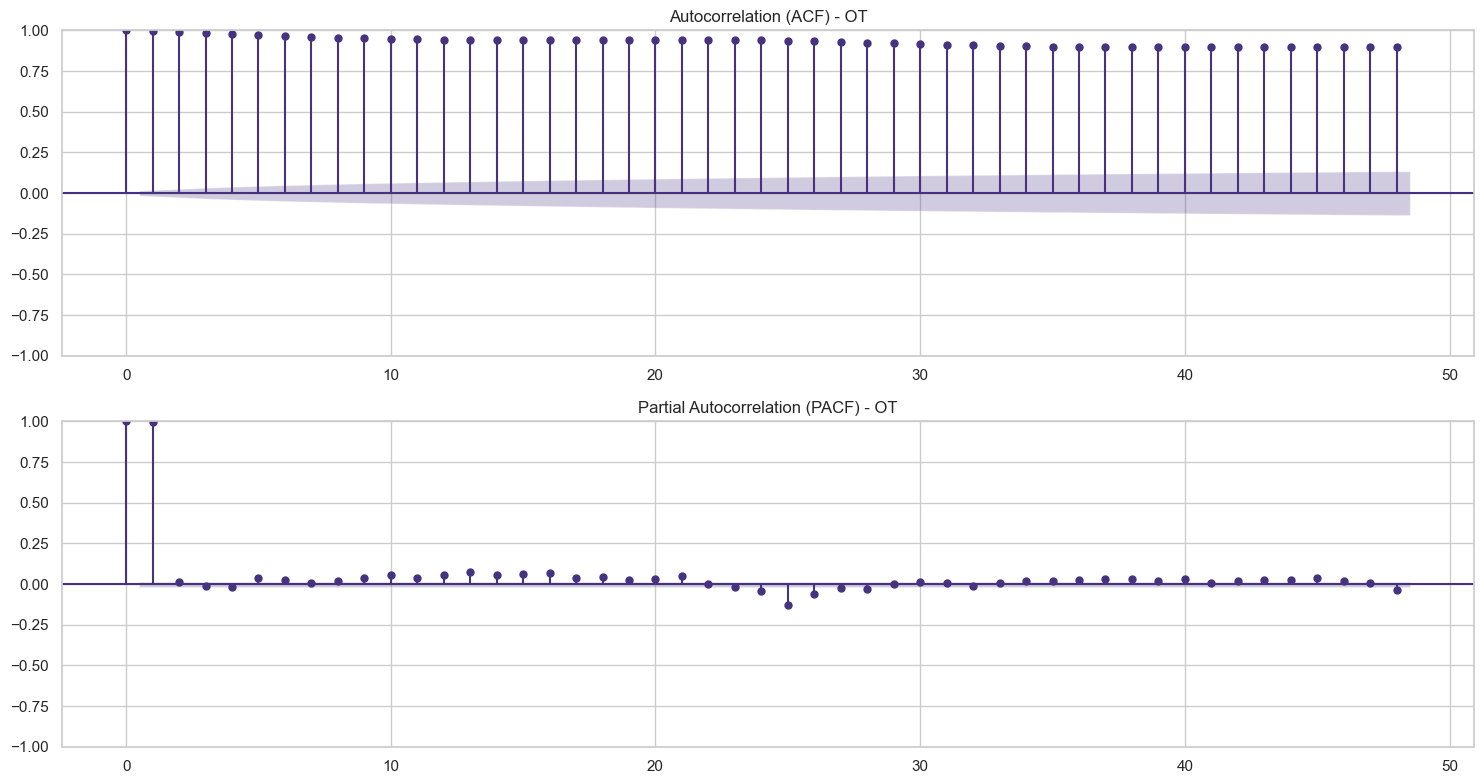

In [14]:
eda.check_stationarity(column='OT')
eda.plot_acf_pacf(column='OT', lags=48)

### 1. Augmented Dickey-Fuller (ADF) Test Results
This is a precise statistical test to determine whether the series has a "Unit Root" (non-stationary).

| Metric | Value | Critical Values | Conclusion |
| :--- | :--- | :--- | :--- |
| **ADF Statistic** | **-3.4880** | 1%: -3.43, 5%: -2.86 | Lower than both 1% and 5% thresholds |
| **p-value** | **0.0083** | 0.05 | **< 0.05** (Statistically significant) |

**Statistical Conclusion:** Reject the null hypothesis $H_0$. The data series is **Stationary**.

---

### 2. Comparison with Autocorrelation Plots (ACF/PACF)
There is a "slight discrepancy" between the visual inspection and the statistical results that requires explanation:

- **Visual (ACF):** The lags decay very slowly $\rightarrow$ Suggests high inertia, making the data "look like" it is non-stationary.
- **Statistical (ADF):** Low p-value $\rightarrow$ Confirms the series is stationary.

**Practical Explanation:**
The Oil Temperature (OT) series is **stationary but has extremely long memory (High Persistence)**.
- It is "stationary" because oil temperature always fluctuates within a specific physical range (e.g., 0°C - 50°C); it does not grow infinitely like stock prices (Random Walk).
- However, it has "high inertia" (ACF decays slowly) because the thermal mass of the oil causes it to heat up and cool down very gradually.